# Exploratory Data Analysis: AI and Job Anxiety on Reddit

**Time spent on this homework:** approximately 18 hours.

## Research question

How did discussions about AI and employment anxiety change in technology- and career-related Reddit communities between 2022 and 2024?

## Questions and hypotheses

During this exploratory analysis, we want to investigate several questions:

1. How did the amount of AI-related discussion change after the appearance of ChatGPT?

   **Hypothesis:** AI-related discussion increased sharply after late 2022 and remained much higher than before the release of ChatGPT.

2. Did job anxiety grow together with AI-related discussion?

   **Hypothesis:** As AI became a more common topic, concerns about job security and replacement also became more frequent.

3. How often are AI discussion and job anxiety mentioned in the same submission?

   **Hypothesis:** Only a part of AI-related discussion is directly connected with employment fears, because users also discuss AI tools, capabilities, models, and other technical topics.

4. Is job anxiety more closely connected with AI attention or with broader labor-market conditions?

   **Hypothesis:** Job anxiety may be related not only to AI development, but also to layoffs, hiring difficulties, and the general state of the job market.

5. In which Reddit communities is job anxiety most visible?

   **Hypothesis:** Career-oriented communities such as r/careerguidance, r/jobs, and r/cscareerquestions are likely to contain a higher share of job-anxiety-related discussion than more general technology communities.

6. Does job anxiety appear differently in submissions and comments?

   **Hypothesis:** Employment concerns are more likely to become the main topic of a submission than to appear inside comments.

7. Do job-anxiety-related comments receive more engagement than other comments?

   **Hypothesis:** Comments discussing employment fears may receive somewhat higher scores because these concerns are relevant to many users, although we do not expect the difference to be very large.

These hypotheses are exploratory. We use them to guide the analysis rather than treating them as assumptions that must be confirmed.

## Dataset setup

The analysis is based on 24 CSV files covering 12 selected months from 2022 to 2024.

For each month, two types of Reddit data are available:
- `RS_` files contain submissions (posts);
- `RC_` files contain comments.

At this stage, we first check that all expected files are available before starting the analysis.

In [39]:
from pathlib import Path
import pandas as pd

DATA_DIR = Path("output")

files = sorted(DATA_DIR.glob("*.csv"))

len(files)

24

In [40]:
common_subreddits = {
    "anthropic",
    "antiwork",
    "artificial",
    "artistlounge",
    "careerguidance",
    "chatgpt",
    "copywriting",
    "cscareerquestions",
    "datascience",
    "experienceddevs",
    "freelance",
    "futurology",
    "graphic_design",
    "itcareerquestions",
    "jobs",
    "journalism",
    "layoffs",
    "learnprogramming",
    "machinelearning",
    "openai",
    "programming",
    "recruitinghell",
    "resumes",
    "singularity",
    "softwareengineering",
    "technology",
    "webdev",
}

## Dataset overview

Before moving to the main analysis, we first look at the basic structure of the dataset.

For each month, we check:
- how many comments and submissions are available;
- how large each monthly dataset is;
- how the amount of data changes over time.

This gives a general understanding of the dataset before moving to more specific questions about AI discussion and job anxiety.

In [42]:
rows = []

for file in files:
    df_temp = pd.read_csv(file, low_memory=False)

    df_temp["subreddit"] = df_temp["subreddit"].astype("string").str.lower()

    df_temp = df_temp[
        df_temp["subreddit"].isin(common_subreddits)
    ]

    file_type = "comment" if file.name.startswith("RC_") else "submission"
    month = file.stem.split("_")[1]

    rows.append({
        "file": file.name,
        "type": file_type,
        "month": month,
        "rows": len(df_temp),
        "columns": len(df_temp.columns),
    })

overview = pd.DataFrame(rows)
overview

,file,type,month,rows,columns
0,RC_2022-04.csv,comment,2022-04,1723718,52
1,RC_2022-11.csv,comment,2022-11,1453025,52
2,RC_2022-12.csv,comment,2022-12,1521445,52
3,RC_2023-01.csv,comment,2023-01,1883262,52
4,RC_2023-03.csv,comment,2023-03,1719817,52
5,RC_2023-04.csv,comment,2023-04,1423880,73
6,RC_2023-07.csv,comment,2023-07,1421079,75
7,RC_2023-11.csv,comment,2023-11,1183031,75
8,RC_2024-04.csv,comment,2024-04,1264170,75
9,RC_2024-05.csv,comment,2024-05,1423328,74


### Activity by month

The next step is to compare the amount of Reddit activity across the selected months.

Looking at monthly activity is useful because the amount of data is not the same in every period. Later, when comparing AI-related discussion or job anxiety, I mainly use percentages rather than only raw counts so that months with more records do not automatically appear more important.

In [48]:
monthly_counts = (
    overview
    .groupby(["month", "type"], as_index=False)["rows"]
    .sum()
)

### Number of submissions by month

We first look at how many submissions were collected in each selected month.

The amount of posting activity changes quite a lot between periods. Some months contain around 40–50 thousand submissions, while others contain close to 100 thousand.

This matters for the later analysis: months with more posts will naturally contain more AI-related or job-anxiety-related posts in absolute numbers. Because of that, we later compare topics mostly using shares and percentages.

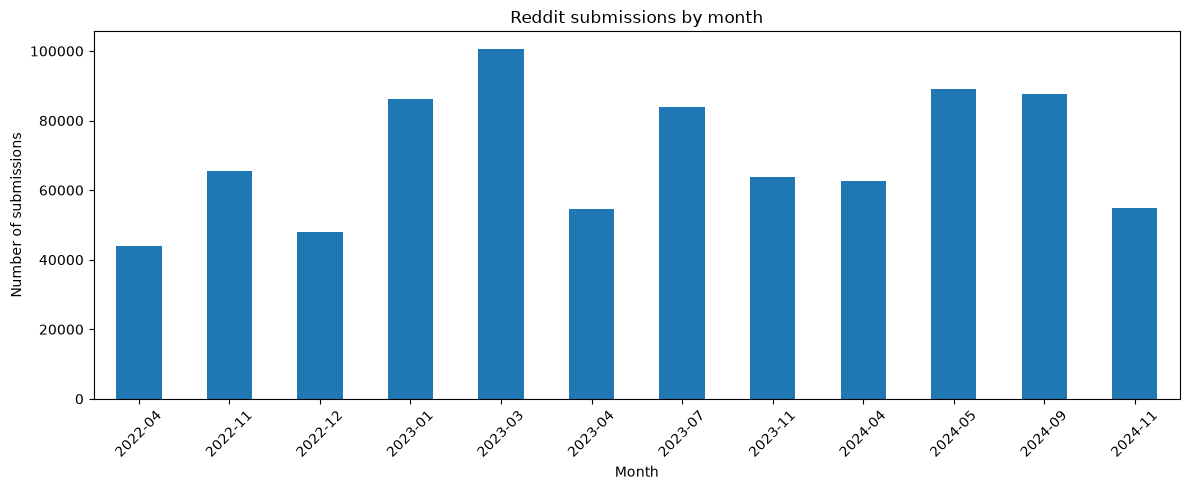

In [49]:
import matplotlib.pyplot as plt

pivot = monthly_counts.pivot(
    index="month",
    columns="type",
    values="rows"
)
pivot["submission"].plot(kind="bar", figsize=(12, 5))

plt.title("Reddit submissions by month")
plt.xlabel("Month")
plt.ylabel("Number of submissions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observation

Submission activity is not stable across the selected months. The highest activity appears around March 2023, while several other months contain noticeably fewer posts.

At this stage, we use this graph mainly as a baseline to understand how large each monthly sample is before moving to more specific topic-based analysis.

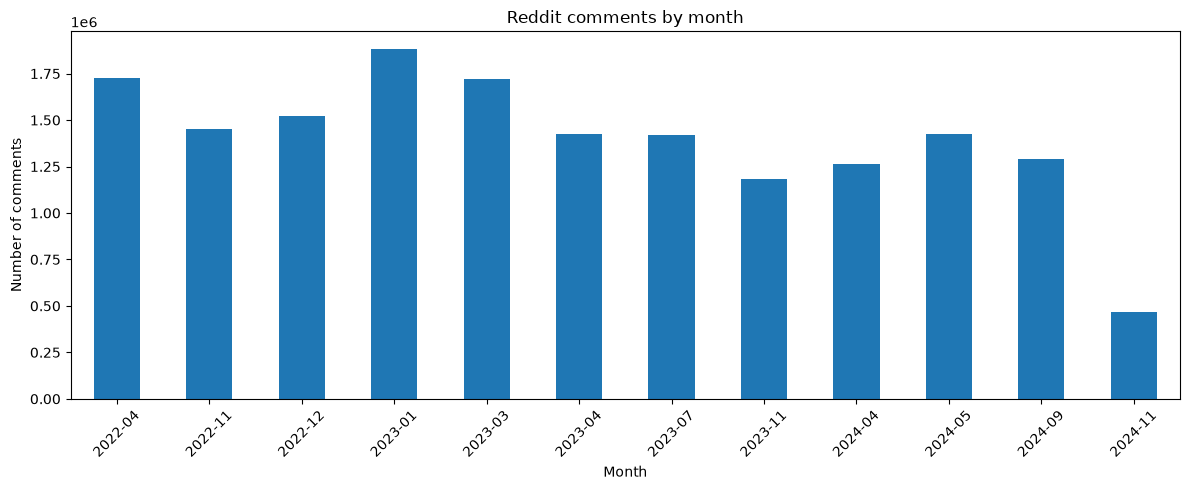

In [50]:
pivot["comment"].plot(kind="bar", figsize=(12, 5))

plt.title("Reddit comments by month")
plt.xlabel("Month")
plt.ylabel("Number of comments")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observation

Comment activity also changes across the selected months. The highest number of comments appears around January 2023, while November 2024 contains much fewer comments than the other periods.

The monthly pattern for comments is different from the pattern for submissions. This suggests that the number of posts and the amount of discussion under them do not always move in the same way.

We use this as additional context before moving to comparisons between different subreddits and topics.

## Which subreddits are the most active?

Next, we look at how submissions are distributed across the selected subreddits.

This helps us understand which communities contribute the largest part of the dataset and which ones are much smaller. It also gives useful context for the later topic analysis.

For example, if a topic appears often in the whole dataset, this may simply be because it is common in one very large subreddit. For this reason, we first compare the total number of submissions in each subreddit before moving to topic-specific shares such as AI discussion and job anxiety.

In [52]:
submission_subreddit_counts = {}

submission_files = [
    file for file in files
    if file.name.startswith("RS_")
]

for file in submission_files:
    df_temp = pd.read_csv(
        file,
        usecols=["subreddit"],
        low_memory=False
    )

    df_temp["subreddit"] = df_temp["subreddit"].astype("string").str.lower()

    df_temp = df_temp[
        df_temp["subreddit"].isin(common_subreddits)
    ]

    counts = df_temp["subreddit"].value_counts()

    for subreddit, count in counts.items():
        submission_subreddit_counts[subreddit] = (
            submission_subreddit_counts.get(subreddit, 0) + count
        )

submission_subreddit_counts = (
    pd.Series(submission_subreddit_counts)
    .sort_values(ascending=False)
)

submission_subreddit_counts

chatgpt                116657
antiwork                99129
careerguidance          94516
jobs                    72421
technology              51449
learnprogramming        43151
cscareerquestions       40387
webdev                  38354
resumes                 29921
recruitinghell          28620
programming             27849
graphic_design          26756
itcareerquestions       21972
singularity             21168
machinelearning         21125
openai                  20564
artistlounge            16711
futurology              13923
datascience             13694
artificial              13107
experienceddevs          6454
journalism               5479
freelance                5000
softwareengineering      4965
copywriting              4474
layoffs                  2170
anthropic                 300
dtype: int64

### Observation

The dataset is distributed quite unevenly across subreddits.

r/ChatGPT contains the largest number of submissions, while r/antiwork, r/careerguidance, and r/jobs also contribute a large amount of content. At the same time, some smaller communities contain only a few thousand submissions.

This difference in subreddit size is important for the later analysis. Raw counts alone may make large communities look more important, so when we compare AI discussion or job anxiety across subreddits, we mainly use percentages within each community.

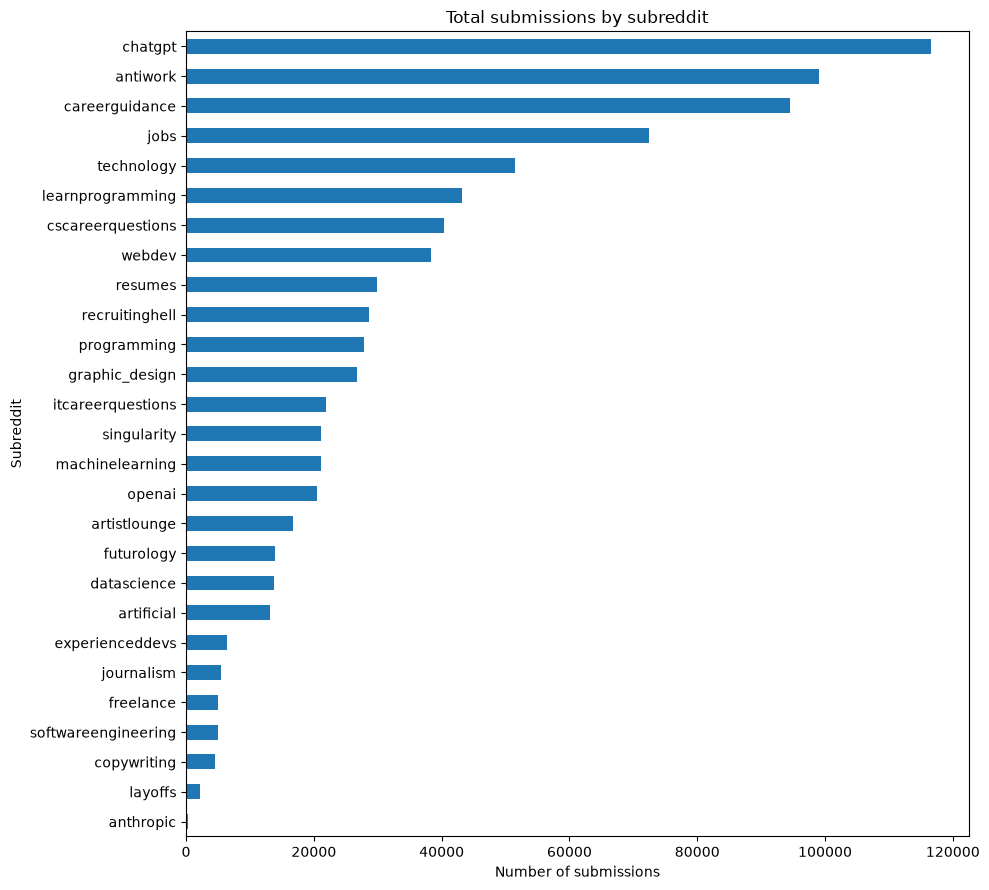

In [53]:
submission_subreddit_counts.sort_values().plot(
    kind="barh",
    figsize=(10, 9)
)

plt.title("Total submissions by subreddit")
plt.xlabel("Number of submissions")
plt.ylabel("Subreddit")
plt.tight_layout()
plt.show()

### How does subreddit activity change over time?

The previous chart shows which subreddits contribute the most submissions overall.

Now we look at how their activity changes across the selected months. A subreddit can be very active in total, but its activity may be concentrated only in a few periods.

This helps us see whether some communities become more active around particular moments and whether the structure of the discussion changes over time.

In [78]:
submission_month_subreddit = []

for file in submission_files:
    month = file.stem.split("_")[1]

    df_temp = pd.read_csv(
        file,
        usecols=["subreddit"],
        low_memory=False
    )

    df_temp["subreddit"] = df_temp["subreddit"].astype("string").str.lower()

    df_temp = df_temp[
        df_temp["subreddit"].isin(common_subreddits)
    ]

    counts = df_temp["subreddit"].value_counts()

    for subreddit, count in counts.items():
        submission_month_subreddit.append({
            "month": month,
            "subreddit": subreddit,
            "count": count
        })

submission_month_subreddit = pd.DataFrame(submission_month_subreddit)

### How does activity change in the largest communities?

To make the comparison easier to read, we focus on the eight subreddits with the largest number of submissions in our dataset.

We then compare how active these communities are across the selected months. This helps us see whether the most active subreddits stay equally important over time or whether some of them become much more active during particular periods.

Looking at this change over time is more useful than only looking at the total number of submissions, because a community may be large overall but especially active during only a few months.

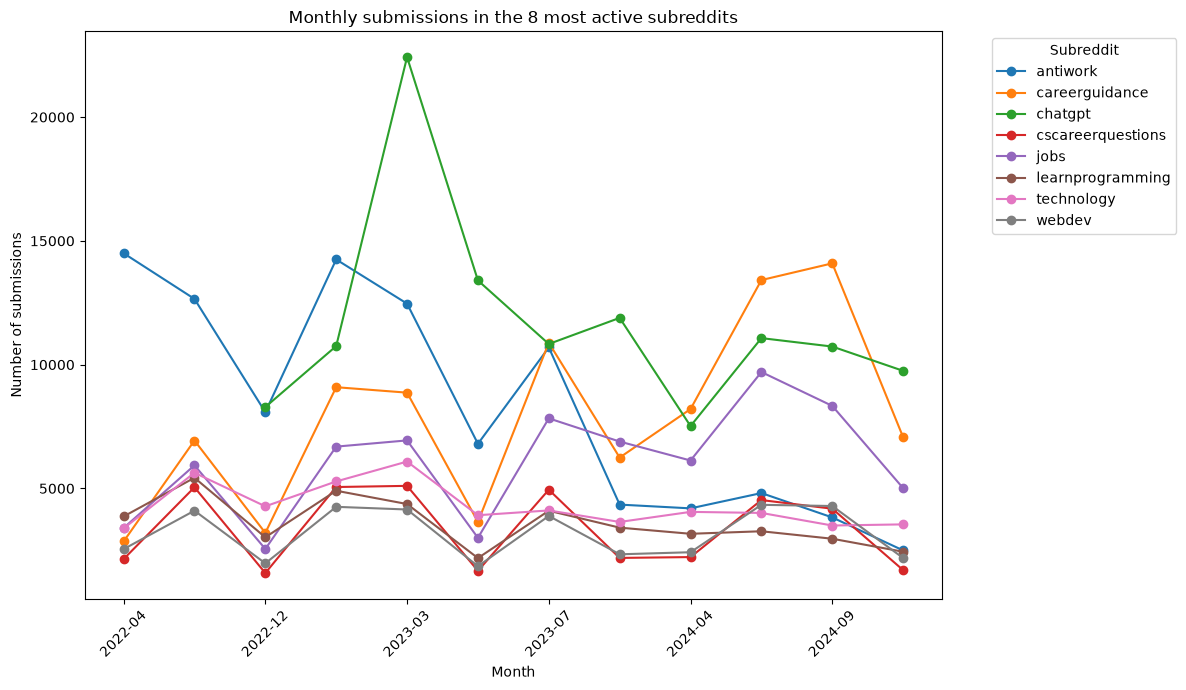

In [ ]:
top8_subreddits = submission_subreddit_counts.head(8).index

top8_monthly = submission_month_subreddit[
    submission_month_subreddit["subreddit"].isin(top8_subreddits)
]

top8_pivot = top8_monthly.pivot(
    index="month",
    columns="subreddit",
    values="count"
)

top8_pivot.plot(
    kind="line",
    marker="o",
    figsize=(12, 7)
)

plt.title("Monthly submissions in the 8 most active subreddits")
plt.xlabel("Month")
plt.ylabel("Number of submissions")
plt.xticks(rotation=45)
plt.legend(title="Subreddit", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Observation

The activity of the largest subreddits changes noticeably over time.

The clearest example is r/ChatGPT, which shows a very strong increase around early 2023. This period also corresponds to the time when ChatGPT and other generative AI tools were becoming much more visible.

Later, especially in 2024, r/careerguidance becomes more active, while several technical communities remain more stable.

This suggests that the structure of discussion changes across periods. Different communities become more active at different moments, so the overall Reddit activity cannot be explained by one subreddit alone.

This is useful for the next part of our analysis, where we move from general activity to the actual content of the discussions: AI-related topics and job anxiety.

## AI-related discussion over time

After looking at the general activity of the selected communities, we move to the content of the discussions.

Our first question is how much attention AI receives across the selected months. To identify AI-related submissions, we use a list of common AI-related terms such as ChatGPT, OpenAI, GPT, LLM, Claude, Gemini, and others.

We search for these terms in the title and text of each submission and calculate what percentage of all submissions in each month is related to AI.

In [81]:
ai_keywords = [
    "artificial intelligence",
    "generative ai",
    "chatgpt",
    "openai",
    "gpt",
    "gpt-3",
    "gpt-4",
    "llm",
    "large language model",
    "claude",
    "gemini",
    "bard",
    "llama",
]

In [94]:
import re

ai_pattern = "|".join(
    re.escape(keyword)
    for keyword in ai_keywords
)

ai_monthly = []

for file in submission_files:
    month = file.stem.split("_")[1]

    df_temp = pd.read_csv(
        file,
        usecols=["subreddit", "title", "selftext"],
        low_memory=False
    )

    df_temp["subreddit"] = df_temp["subreddit"].astype("string").str.lower()

    df_temp = df_temp[
        df_temp["subreddit"].isin(common_subreddits)
    ]

    df_temp["title"] = df_temp["title"].fillna("")
    df_temp["selftext"] = df_temp["selftext"].fillna("")

    text = (
        df_temp["title"] + " " + df_temp["selftext"]
    ).str.lower()

    ai_mask = text.str.contains(
        ai_pattern,
        regex=True,
        na=False
    )

    total = len(df_temp)
    ai_count = ai_mask.sum()

    ai_monthly.append({
        "month": month,
        "total_submissions": total,
        "ai_submissions": ai_count,
        "ai_share_pct": ai_count / total * 100
    })

ai_monthly = pd.DataFrame(ai_monthly).sort_values("month")

### Observation

We see a sharp increase in AI-related submissions after late 2022.

Before the release of ChatGPT, AI-related posts made up less than 1% of submissions in the selected communities. In December 2022, this share increased to more than 13%, and it reached its highest level in April 2023 at over 23%.

After that, the share decreases, but it remains much higher than before late 2022. This suggests that AI became a much more visible and stable topic in these communities after the appearance of ChatGPT.

## Job anxiety over time

After looking at general AI-related discussion, we now focus on a more specific question: how often users express concerns about job security, losing their jobs, or being replaced by AI.

To identify these submissions, we use a narrower set of keywords related to explicit employment fear and replacement concerns. We intentionally keep this list separate from broader topics such as layoffs or the general job market, because we want to measure job anxiety itself more clearly.

In [95]:
job_anxiety_keywords = [
    "lose my job",
    "losing my job",
    "take my job",
    "replace me",
    "replaced by ai",
    "replaced by artificial intelligence",
    "job security",
    "career threat",
    "fear of ai",
    "worried about ai",
    "afraid of ai",
    "scared of ai",
    "obsolete",
]

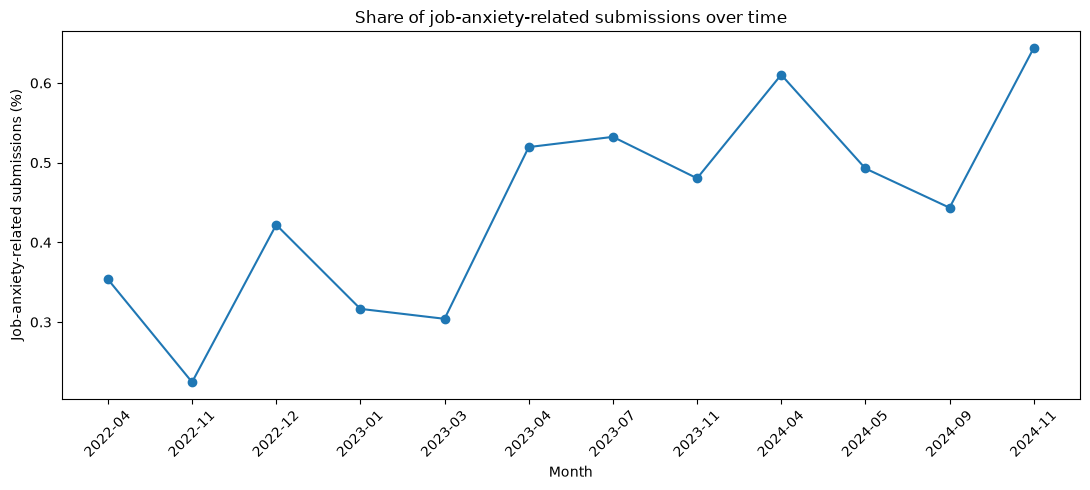

In [101]:
job_pattern = "|".join(
    re.escape(keyword)
    for keyword in job_anxiety_keywords
)

job_anxiety_monthly = []

for file in submission_files:
    month = file.stem.split("_")[1]

    df_temp = pd.read_csv(
        file,
        usecols=["subreddit", "title", "selftext"],
        low_memory=False
    )

    df_temp["subreddit"] = (
        df_temp["subreddit"]
        .astype("string")
        .str.lower()
    )

    df_temp = df_temp[
        df_temp["subreddit"].isin(common_subreddits)
    ]

    df_temp["title"] = df_temp["title"].fillna("")
    df_temp["selftext"] = df_temp["selftext"].fillna("")

    text = (
        df_temp["title"] + " " + df_temp["selftext"]
    ).str.lower()

    job_mask = text.str.contains(
        job_pattern,
        regex=True,
        na=False
    )

    total = len(df_temp)
    job_count = job_mask.sum()

    job_anxiety_monthly.append({
        "month": month,
        "total_submissions": total,
        "job_anxiety_submissions": job_count,
        "job_anxiety_share_pct": job_count / total * 100
    })

job_anxiety_monthly = (
    pd.DataFrame(job_anxiety_monthly)
    .sort_values("month")
)

plt.figure(figsize=(11, 5))

plt.plot(
    job_anxiety_monthly["month"],
    job_anxiety_monthly["job_anxiety_share_pct"],
    marker="o"
)

plt.title("Share of job-anxiety-related submissions over time")
plt.xlabel("Month")
plt.ylabel("Job-anxiety-related submissions (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observation

The share of job-anxiety-related submissions remains relatively small, but we can see a general increase over time.

In April 2022, around 0.35% of submissions contain explicit job-anxiety-related language. By November 2024, this share reaches about 0.64%, which is the highest value among the selected months.

The pattern is not steady. There are several increases and decreases throughout the observed period. However, the later months generally show higher levels than the earliest ones.

This suggests that explicit concerns about job security and replacement became somewhat more visible over time, even though they still represent a small part of all submissions.

## AI discussion and job anxiety

Now we compare AI-related discussion and job anxiety directly.

We want to check whether months with more AI-related submissions also have more explicit concerns about jobs and replacement. This helps us test our initial idea that growing attention to AI may be connected with growing job anxiety.

In [102]:
comparison = ai_monthly[
    ["month", "ai_share_pct"]
].merge(
    job_anxiety_monthly[
        ["month", "job_anxiety_share_pct"]
    ],
    on="month"
)

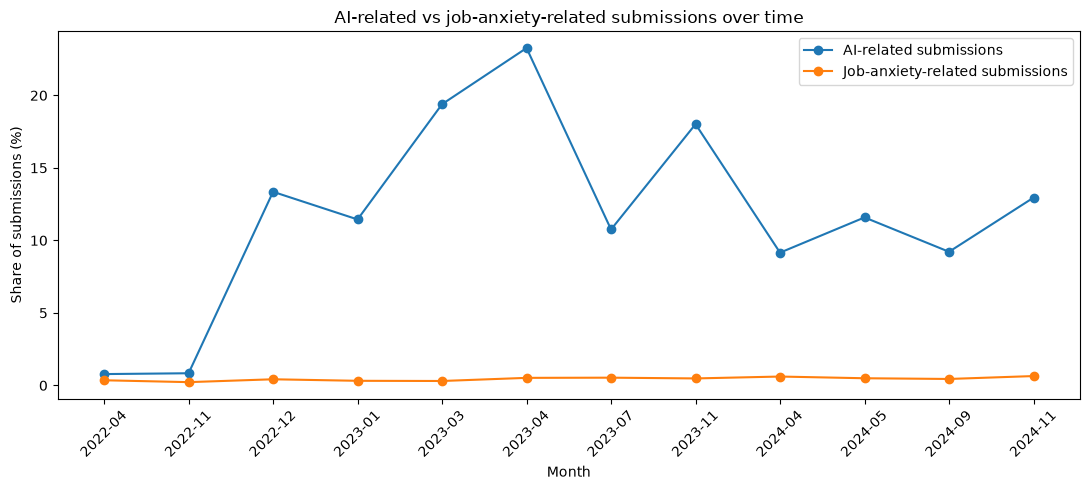

In [103]:
plt.figure(figsize=(11, 5))

plt.plot(
    comparison["month"],
    comparison["ai_share_pct"],
    marker="o",
    label="AI-related submissions"
)

plt.plot(
    comparison["month"],
    comparison["job_anxiety_share_pct"],
    marker="o",
    label="Job-anxiety-related submissions"
)

plt.title("AI-related vs job-anxiety-related submissions over time")
plt.xlabel("Month")
plt.ylabel("Share of submissions (%)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

### Observation

The two trends behave quite differently.

AI-related discussion rises very sharply after late 2022 and reaches its highest level in spring 2023. Job anxiety changes much more gradually and stays at a much lower level throughout the whole period.

We do not see job anxiety increasing proportionally with AI discussion. For example, the strongest AI peaks in early 2023 are not matched by equally strong peaks in job anxiety.

This suggests that a higher level of AI discussion does not automatically mean that users express more fear about losing their jobs. This leads us to a more specific question: when people talk about AI, how often do they also mention job anxiety in the same submission?

### How often do AI-related posts also contain job anxiety?

To answer this question, we look only at AI-related submissions and check how many of them also contain job-anxiety-related language.

This gives us a more direct way to test whether AI discussion itself is closely connected with employment fears.

In [104]:
ai_job_overlap_monthly = []

for file in submission_files:
    month = file.stem.split("_")[1]

    df_temp = pd.read_csv(
        file,
        usecols=["subreddit", "title", "selftext"],
        low_memory=False
    )

    df_temp["subreddit"] = df_temp["subreddit"].astype("string").str.lower()

    df_temp = df_temp[
        df_temp["subreddit"].isin(common_subreddits)
    ]

    df_temp["title"] = df_temp["title"].fillna("")
    df_temp["selftext"] = df_temp["selftext"].fillna("")

    text = (
        df_temp["title"] + " " + df_temp["selftext"]
    ).str.lower()

    ai_mask = text.str.contains(
        ai_pattern,
        regex=True,
        na=False
    )

    job_mask = text.str.contains(
        job_pattern,
        regex=True,
        na=False
    )

    ai_count = ai_mask.sum()

    ai_and_job_count = (ai_mask & job_mask).sum()

    overlap_share = (
        ai_and_job_count / ai_count * 100
        if ai_count > 0 else 0
    )

    ai_job_overlap_monthly.append({
        "month": month,
        "ai_submissions": ai_count,
        "ai_and_job_anxiety_submissions": ai_and_job_count,
        "job_anxiety_within_ai_pct": overlap_share
    })

ai_job_overlap_monthly = (
    pd.DataFrame(ai_job_overlap_monthly)
    .sort_values("month")
)

ai_job_overlap_monthly

,month,ai_submissions,ai_and_job_anxiety_submissions,job_anxiety_within_ai_pct
0,2022-04,342,3,0.877193
1,2022-11,548,1,0.182482
2,2022-12,6389,47,0.735639
3,2023-01,9869,52,0.526902
4,2023-03,19514,71,0.363841
5,2023-04,12670,55,0.434096
6,2023-07,9006,51,0.566289
7,2023-11,11475,47,0.409586
8,2024-04,5744,27,0.470056
9,2024-05,10319,32,0.310108


### Observation

The overlap between AI-related discussion and job anxiety remains quite small throughout the whole period.

In most months, less than 1% of AI-related submissions also contain explicit job-anxiety language. Even during periods when AI discussion is very high, the share of posts that also mention employment fear remains relatively stable.

This means that our initial assumption is only weakly supported. AI-related discussion grows strongly, but job anxiety does not grow at the same rate inside those discussions.

This suggests that many AI-related posts focus on other topics such as technology, tools, capabilities, or general interest rather than directly on fear of job loss.

## What may be connected with job anxiety?

Since job anxiety does not seem to rise directly with AI discussion, we next look at other possible factors.

We compare job anxiety with three broader topics:
- layoffs;
- the job market and hiring;
- general economic discussion.

This helps us check whether employment anxiety may be more closely connected with labor-market conditions than with AI discussion itself.

In [116]:
layoff_keywords = [
    "layoff",
    "layoffs",
    "laid off",
    "fired",
    "downsizing",
]

job_market_keywords = [
    "job market",
    "hiring",
    "hiring freeze",
    "can't find a job",
    "cannot find a job",
    "no jobs",
    "applications",
    "interview",
]

economy_keywords = [
    "recession",
    "economy",
    "economic",
    "inflation",
    "unemployment",
]


def make_pattern(keywords):
    return "|".join(
        re.escape(keyword)
        for keyword in keywords
    )


layoff_pattern = make_pattern(layoff_keywords)
job_market_pattern = make_pattern(job_market_keywords)
economy_pattern = make_pattern(economy_keywords)


context_monthly = []

for file in submission_files:
    month = file.stem.split("_")[1]

    df_temp = pd.read_csv(
        file,
        usecols=["subreddit", "title", "selftext"],
        low_memory=False
    )

    df_temp["subreddit"] = df_temp["subreddit"].astype("string").str.lower()

    df_temp = df_temp[
        df_temp["subreddit"].isin(common_subreddits)
    ]

    df_temp["title"] = df_temp["title"].fillna("")
    df_temp["selftext"] = df_temp["selftext"].fillna("")

    text = (
        df_temp["title"] + " " + df_temp["selftext"]
    ).str.lower()

    layoff_mask = text.str.contains(
        layoff_pattern,
        regex=True,
        na=False
    )

    job_market_mask = text.str.contains(
        job_market_pattern,
        regex=True,
        na=False
    )

    economy_mask = text.str.contains(
        economy_pattern,
        regex=True,
        na=False
    )

    total = len(df_temp)

    context_monthly.append({
        "month": month,
        "layoff_share_pct": layoff_mask.sum() / total * 100,
        "job_market_share_pct": job_market_mask.sum() / total * 100,
        "economy_share_pct": economy_mask.sum() / total * 100,
    })


context_monthly = (
    pd.DataFrame(context_monthly)
    .sort_values("month")
)

### Which topics move together with job anxiety?

Now we compare the monthly share of job anxiety with the monthly shares of layoffs, job-market discussion, and broader economic discussion.

We use correlation here as a simple way to check which topics tend to increase and decrease together across the selected months.

A higher positive correlation means that two topics tend to move in a similar direction over time.

In [119]:
context_comparison = context_monthly.merge(
    job_anxiety_monthly[
        ["month", "job_anxiety_share_pct"]
    ],
    on="month"
)

context_comparison[
    [
        "job_anxiety_share_pct",
        "layoff_share_pct",
        "job_market_share_pct",
        "economy_share_pct",
    ]
].corr()

,job_anxiety_share_pct,layoff_share_pct,job_market_share_pct,economy_share_pct
job_anxiety_share_pct,1.000000,0.706077,0.803663,0.657938
layoff_share_pct,0.706077,1.000000,0.891607,0.654301
job_market_share_pct,0.803663,0.891607,1.000000,0.724344
economy_share_pct,0.657938,0.654301,0.724344,1.000000


### Observation

Job anxiety is most strongly related to discussion about the job market, with a correlation of about 0.80.

The relationship with layoffs is also fairly strong, at about 0.71. The connection with broader economic discussion is weaker, but still noticeable, at about 0.66.

This suggests that job anxiety in our dataset may be more closely connected with hiring conditions, difficulties in the job market, and layoffs than with broader economic discussion.

At the same time, correlation does not show that one topic causes another. It only means that these topics tend to increase and decrease in a similar way across the selected months.

## Where is job anxiety most common?

After looking at how job anxiety changes over time, we now compare different subreddits.

We calculate what percentage of submissions in each subreddit contains job-anxiety-related language. Using percentages allows us to compare large and small communities more fairly.

In [120]:
job_anxiety_by_subreddit = []

for file in submission_files:
    df_temp = pd.read_csv(
        file,
        usecols=["subreddit", "title", "selftext"],
        low_memory=False
    )

    df_temp["subreddit"] = df_temp["subreddit"].astype("string").str.lower()

    df_temp = df_temp[
        df_temp["subreddit"].isin(common_subreddits)
    ]

    df_temp["title"] = df_temp["title"].fillna("")
    df_temp["selftext"] = df_temp["selftext"].fillna("")

    text = (
        df_temp["title"] + " " + df_temp["selftext"]
    ).str.lower()

    df_temp["job_anxiety"] = text.str.contains(
        job_pattern,
        regex=True,
        na=False
    )

    grouped = (
        df_temp
        .groupby("subreddit")
        .agg(
            total_submissions=("job_anxiety", "size"),
            job_anxiety_submissions=("job_anxiety", "sum")
        )
        .reset_index()
    )

    job_anxiety_by_subreddit.append(grouped)

job_anxiety_by_subreddit = pd.concat(
    job_anxiety_by_subreddit,
    ignore_index=True
)

job_anxiety_by_subreddit = (
    job_anxiety_by_subreddit
    .groupby("subreddit", as_index=False)
    .sum()
)

job_anxiety_by_subreddit["job_anxiety_share_pct"] = (
    job_anxiety_by_subreddit["job_anxiety_submissions"]
    / job_anxiety_by_subreddit["total_submissions"]
    * 100
)

job_anxiety_by_subreddit = (
    job_anxiety_by_subreddit
    .sort_values("job_anxiety_share_pct", ascending=False)
)

job_anxiety_by_subreddit

,subreddit,total_submissions,job_anxiety_submissions,job_anxiety_share_pct
16,layoffs,2170,40,1.843318
4,careerguidance,94516,1037,1.097169
23,singularity,21168,176,0.831444
7,cscareerquestions,40387,305,0.755194
14,jobs,72421,541,0.747021
13,itcareerquestions,21972,149,0.678136
9,experienceddevs,6454,37,0.573288
1,antiwork,99129,558,0.562903
11,futurology,13923,70,0.502765
2,artificial,13107,45,0.343328


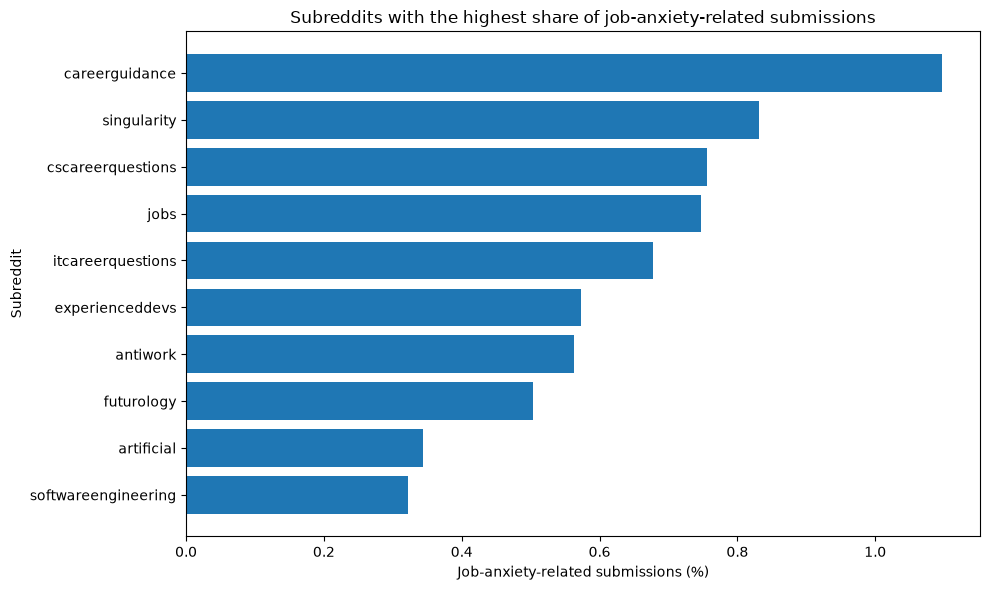

In [121]:
plot_data = (
    job_anxiety_by_subreddit[
        job_anxiety_by_subreddit["subreddit"] != "layoffs"
    ]
    .head(10)
    .sort_values("job_anxiety_share_pct")
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_data["subreddit"],
    plot_data["job_anxiety_share_pct"]
)

plt.title("Subreddits with the highest share of job-anxiety-related submissions")
plt.xlabel("Job-anxiety-related submissions (%)")
plt.ylabel("Subreddit")
plt.tight_layout()
plt.show()

### Observation

Job anxiety is not distributed equally across communities.

Among the larger subreddits, the highest shares appear in career-related communities such as r/careerguidance, r/cscareerquestions, r/jobs, and r/itcareerquestions.

At the same time, r/singularity also has a relatively high share, which is interesting because it is more focused on AI, technology, and the future.

This suggests that explicit employment concerns are especially visible in communities where people discuss careers and future changes in technology.

## AI discussion in comments

So far, we have focused mainly on submissions. Now we look at comments to see whether AI-related discussion behaves in the same way there.

For each month, we calculate what percentage of comments contains AI-related terms.

This allows us to compare two different types of Reddit activity: creating a new post and discussing a topic inside comments.

In [ ]:
comment_files = [
    file for file in files
    if file.name.startswith("RC_")
]
ai_comments_monthly = []

for file in comment_files:
    month = file.stem.split("_")[1]

    df_temp = pd.read_csv(
        file,
        usecols=["subreddit", "body"],
        low_memory=False
    )

    df_temp["subreddit"] = df_temp["subreddit"].astype("string").str.lower()

    df_temp = df_temp[
        df_temp["subreddit"].isin(common_subreddits)
    ]

    df_temp["body"] = df_temp["body"].fillna("")

    text = df_temp["body"].str.lower()

    ai_mask = text.str.contains(
        ai_pattern,
        regex=True,
        na=False
    )

    total = len(df_temp)
    ai_count = ai_mask.sum()

    ai_comments_monthly.append({
        "month": month,
        "total_comments": total,
        "ai_comments": ai_count,
        "ai_share_pct": ai_count / total * 100
    })

ai_comments_monthly = (
    pd.DataFrame(ai_comments_monthly)
    .sort_values("month")
)

,month,total_comments,ai_comments,ai_share_pct
0,2022-04,1723718,2102,0.121946
1,2022-11,1453025,2276,0.156639
2,2022-12,1521445,25968,1.706798
3,2023-01,1883262,52665,2.796478
4,2023-03,1719817,94186,5.476513
5,2023-04,1423880,74813,5.254165
6,2023-07,1421079,61194,4.306165
7,2023-11,1183031,63472,5.365202
8,2024-04,1264170,34045,2.693071
9,2024-05,1423328,69762,4.901330


In [ ]:
ai_posts_vs_comments = ai_monthly[
    ["month", "ai_share_pct"]
].rename(
    columns={"ai_share_pct": "submission_ai_share_pct"}
).merge(
    ai_comments_monthly[
        ["month", "ai_share_pct"]
    ].rename(
        columns={"ai_share_pct": "comment_ai_share_pct"}
    ),
    on="month"
)


,month,submission_ai_share_pct,comment_ai_share_pct
0,2022-04,0.780323,0.121946
1,2022-11,0.837255,0.156639
2,2022-12,13.349631,1.706798
3,2023-01,11.443248,2.796478
4,2023-03,19.391446,5.476513
5,2023-04,23.262646,5.254165
6,2023-07,10.751122,4.306165
7,2023-11,18.015260,5.365202
8,2024-04,9.153931,2.693071
9,2024-05,11.582539,4.901330


### AI discussion in submissions and comments

Now we compare AI-related discussion in submissions and comments.

This helps us see whether AI mainly appears as a topic for new posts or whether it is equally common inside comment discussions.

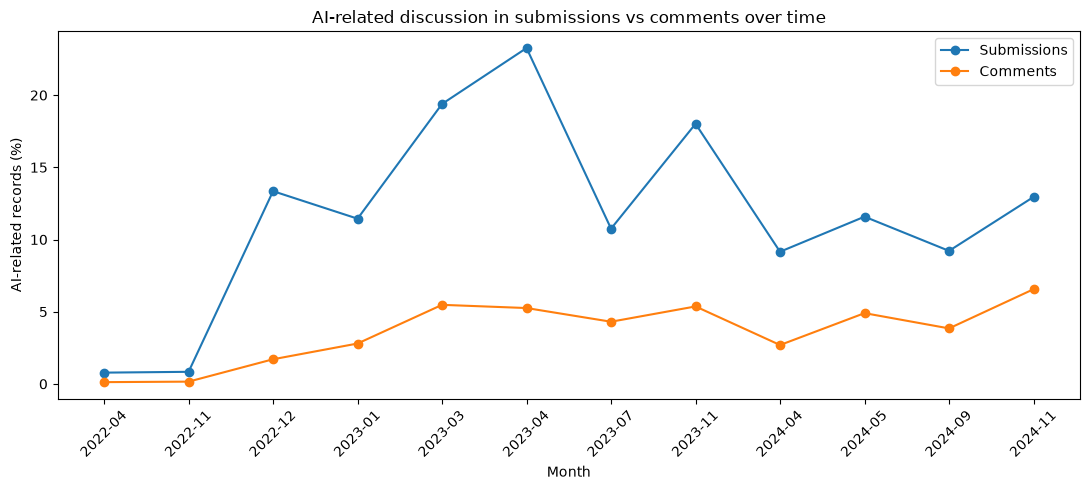

In [125]:
plt.figure(figsize=(11, 5))

plt.plot(
    ai_posts_vs_comments["month"],
    ai_posts_vs_comments["submission_ai_share_pct"],
    marker="o",
    label="Submissions"
)

plt.plot(
    ai_posts_vs_comments["month"],
    ai_posts_vs_comments["comment_ai_share_pct"],
    marker="o",
    label="Comments"
)

plt.title("AI-related discussion in submissions vs comments over time")
plt.xlabel("Month")
plt.ylabel("AI-related records (%)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

### Observation

AI-related discussion is consistently more common in submissions than in comments.

The difference becomes especially visible after late 2022. AI-related submissions increase very sharply, while AI-related comments grow more gradually.

Both types of activity follow a similar general pattern, with higher levels after the appearance of ChatGPT. However, the share of AI-related content remains much higher among submissions.

This suggests that AI is often important enough to become the main topic of a separate post, while it appears less frequently as part of broader comment discussions.

In [128]:
job_comments_monthly = []

for file in comment_files:
    month = file.stem.split("_")[1]

    df_temp = pd.read_csv(
        file,
        usecols=["subreddit", "body"],
        low_memory=False
    )

    df_temp["subreddit"] = df_temp["subreddit"].astype("string").str.lower()

    df_temp = df_temp[
        df_temp["subreddit"].isin(common_subreddits)
    ]

    df_temp["body"] = df_temp["body"].fillna("")

    text = df_temp["body"].str.lower()

    job_mask = text.str.contains(
        job_pattern,
        regex=True,
        na=False
    )

    total = len(df_temp)
    job_count = job_mask.sum()

    job_comments_monthly.append({
        "month": month,
        "total_comments": total,
        "job_anxiety_comments": job_count,
        "job_anxiety_share_pct": job_count / total * 100
    })

job_comments_monthly = (
    pd.DataFrame(job_comments_monthly)
    .sort_values("month")
)


In [129]:
job_posts_vs_comments = job_anxiety_monthly[
    ["month", "job_anxiety_share_pct"]
].rename(
    columns={"job_anxiety_share_pct": "submission_job_anxiety_share_pct"}
).merge(
    job_comments_monthly[
        ["month", "job_anxiety_share_pct"]
    ].rename(
        columns={"job_anxiety_share_pct": "comment_job_anxiety_share_pct"}
    ),
    on="month"
)

## Job anxiety in submissions and comments

Now we compare job-anxiety-related discussion in submissions and comments.

This helps us see whether employment concerns are more often used as the main topic of a post or mentioned inside ongoing discussions.

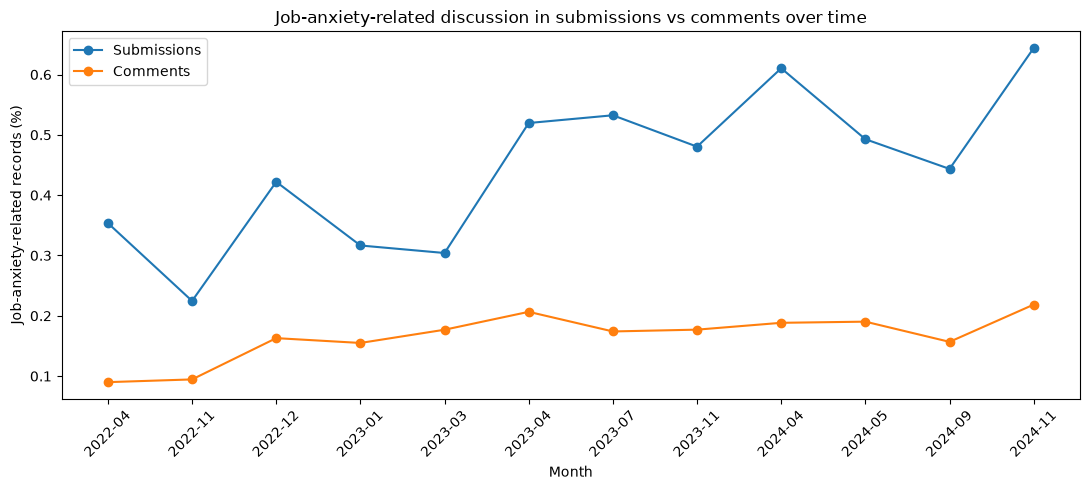

In [130]:
plt.figure(figsize=(11, 5))

plt.plot(
    job_posts_vs_comments["month"],
    job_posts_vs_comments["submission_job_anxiety_share_pct"],
    marker="o",
    label="Submissions"
)

plt.plot(
    job_posts_vs_comments["month"],
    job_posts_vs_comments["comment_job_anxiety_share_pct"],
    marker="o",
    label="Comments"
)

plt.title("Job-anxiety-related discussion in submissions vs comments over time")
plt.xlabel("Month")
plt.ylabel("Job-anxiety-related records (%)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

### Observation

Job-anxiety-related language is consistently more common in submissions than in comments.

The share in submissions is several times higher across most of the observed months. This suggests that concerns about job security and replacement are more often important enough to become the main topic of a post.

Comments show the same general direction, but the values stay much lower. This means that job anxiety is mentioned inside discussions too, but less often than it appears as the main subject of a submission.

The gap between submissions and comments remains visible throughout the whole period, even when both increase.

## Do job-anxiety comments receive more attention?

Next, we compare the Reddit score of job-anxiety-related comments with the score of other comments.

Reddit score reflects the balance of upvotes and downvotes, so it gives us a simple way to see whether comments about job anxiety tend to receive more positive attention from other users.

We compare both the median and the mean score for each month. The median is especially useful here because a small number of very popular comments can strongly increase the mean.

In [131]:
comment_score_comparison = []

for file in comment_files:
    month = file.stem.split("_")[1]

    df_temp = pd.read_csv(
        file,
        usecols=["subreddit", "body", "score"],
        low_memory=False
    )

    df_temp["subreddit"] = df_temp["subreddit"].astype("string").str.lower()

    df_temp = df_temp[
        df_temp["subreddit"].isin(common_subreddits)
    ]

    df_temp["body"] = df_temp["body"].fillna("")

    text = df_temp["body"].str.lower()

    job_mask = text.str.contains(
        job_pattern,
        regex=True,
        na=False
    )

    job_scores = df_temp.loc[job_mask, "score"]
    other_scores = df_temp.loc[~job_mask, "score"]

    comment_score_comparison.append({
        "month": month,
        "job_anxiety_median_score": job_scores.median(),
        "other_comments_median_score": other_scores.median(),
        "job_anxiety_mean_score": job_scores.mean(),
        "other_comments_mean_score": other_scores.mean()
    })

comment_score_comparison = (
    pd.DataFrame(comment_score_comparison)
    .sort_values("month")
)

comment_score_comparison

,month,job_anxiety_median_score,other_comments_median_score,job_anxiety_mean_score,other_comments_mean_score
0,2022-04,2.0,1.0,14.267569,13.031430
1,2022-11,2.0,1.0,9.573197,12.580203
2,2022-12,2.0,2.0,9.998790,12.620359
3,2023-01,2.0,1.0,18.583962,11.623983
4,2023-03,2.0,1.0,11.489481,10.665963
5,2023-04,2.0,1.0,9.126148,11.383071
6,2023-07,1.0,1.0,2.797008,3.413293
7,2023-11,2.0,2.0,12.262655,10.393786
8,2024-04,2.0,1.0,9.669047,10.584213
9,2024-05,1.0,1.0,8.409897,9.975344


### Observation

The difference in scores between job-anxiety-related comments and other comments is relatively small.

In many months, the median score of job-anxiety comments is around 2, while the median score of other comments is around 1. However, this pattern is not present in every month.

The mean scores show a less consistent picture. In some months, job-anxiety comments receive a higher average score, while in others their average score is lower than for other comments.

Overall, we do not see a strong and consistent difference in engagement. Job-anxiety-related comments may receive slightly more attention in some periods, but the pattern changes across months.

## Where does job anxiety appear most often in comments?

So far, we have compared job anxiety in submissions and comments over time. Now we look at differences between communities.

We calculate the share of job-anxiety-related comments within each subreddit to see where employment concerns appear most often in ongoing discussions.

In [132]:
job_anxiety_comments_by_subreddit = []

for file in comment_files:
    df_temp = pd.read_csv(
        file,
        usecols=["subreddit", "body"],
        low_memory=False
    )

    df_temp["subreddit"] = df_temp["subreddit"].astype("string").str.lower()

    df_temp = df_temp[
        df_temp["subreddit"].isin(common_subreddits)
    ]

    df_temp["body"] = df_temp["body"].fillna("")

    text = df_temp["body"].str.lower()

    df_temp["job_anxiety"] = text.str.contains(
        job_pattern,
        regex=True,
        na=False
    )

    grouped = (
        df_temp
        .groupby("subreddit")
        .agg(
            total_comments=("job_anxiety", "size"),
            job_anxiety_comments=("job_anxiety", "sum")
        )
        .reset_index()
    )

    job_anxiety_comments_by_subreddit.append(grouped)


job_anxiety_comments_by_subreddit = pd.concat(
    job_anxiety_comments_by_subreddit,
    ignore_index=True
)

job_anxiety_comments_by_subreddit = (
    job_anxiety_comments_by_subreddit
    .groupby("subreddit", as_index=False)
    .sum()
)

job_anxiety_comments_by_subreddit["job_anxiety_share_pct"] = (
    job_anxiety_comments_by_subreddit["job_anxiety_comments"]
    / job_anxiety_comments_by_subreddit["total_comments"]
    * 100
)

job_anxiety_comments_by_subreddit = (
    job_anxiety_comments_by_subreddit
    .sort_values("job_anxiety_share_pct", ascending=False)
)

,subreddit,total_comments,job_anxiety_comments,job_anxiety_share_pct
16,layoffs,71246,311,0.436516
24,softwareengineering,20221,78,0.385738
23,singularity,757993,2846,0.375465
2,artificial,68840,232,0.337013
7,cscareerquestions,754205,2220,0.294350
11,futurology,1090523,3192,0.292704
0,anthropic,722,2,0.277008
13,itcareerquestions,259317,701,0.270326
4,careerguidance,632701,1540,0.243401
9,experienceddevs,215552,489,0.226859


### Submissions vs comments across subreddits

Now we compare the share of job-anxiety-related submissions with the share of job-anxiety-related comments in each subreddit.

This helps us see whether job anxiety is more often used as the main topic of a post or mentioned inside comments in different communities.

We also calculate the difference between the two percentages. A larger positive difference means that job anxiety appears much more often in submissions than in comments.

In [133]:
job_anxiety_subreddit_comparison = (
    job_anxiety_by_subreddit[
        ["subreddit", "job_anxiety_share_pct"]
    ]
    .rename(
        columns={
            "job_anxiety_share_pct": "submission_job_anxiety_pct"
        }
    )
    .merge(
        job_anxiety_comments_by_subreddit[
            ["subreddit", "job_anxiety_share_pct"]
        ].rename(
            columns={
                "job_anxiety_share_pct": "comment_job_anxiety_pct"
            }
        ),
        on="subreddit"
    )
)

job_anxiety_subreddit_comparison["difference_pct_points"] = (
    job_anxiety_subreddit_comparison["submission_job_anxiety_pct"]
    - job_anxiety_subreddit_comparison["comment_job_anxiety_pct"]
)

job_anxiety_subreddit_comparison = (
    job_anxiety_subreddit_comparison
    .sort_values("difference_pct_points", ascending=False)
)

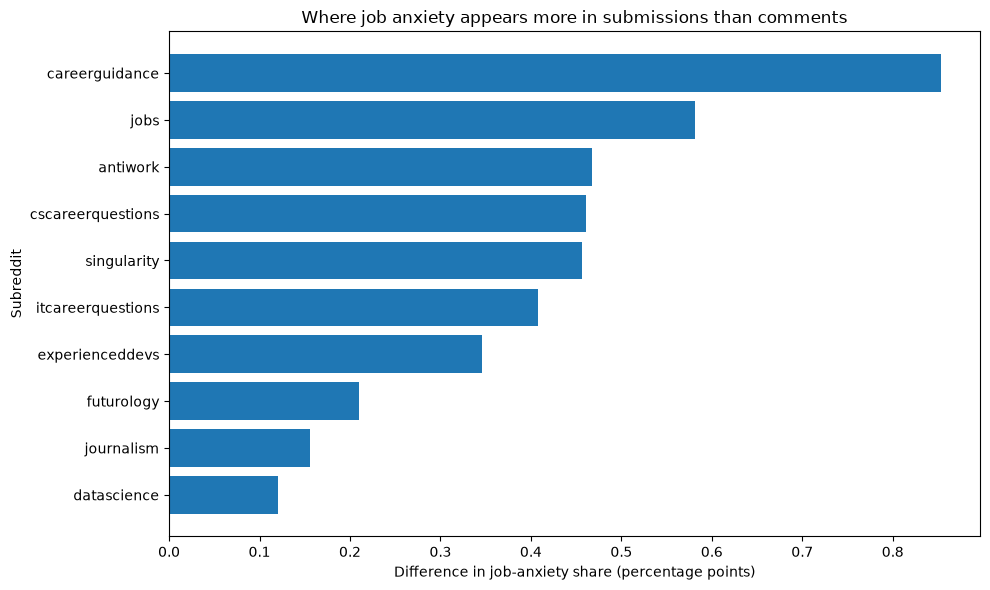

In [134]:
plot_data = (
    job_anxiety_subreddit_comparison[
        job_anxiety_subreddit_comparison["subreddit"] != "layoffs"
    ]
    .head(10)
    .sort_values("difference_pct_points")
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_data["subreddit"],
    plot_data["difference_pct_points"]
)

plt.title("Where job anxiety appears more in submissions than comments")
plt.xlabel("Difference in job-anxiety share (percentage points)")
plt.ylabel("Subreddit")
plt.tight_layout()
plt.show()

### Observation

The difference between submissions and comments varies across communities.

In several career-related subreddits, job anxiety appears much more often in submissions than in comments. This means that employment concerns are more likely to become the main topic of a post in these communities.

The largest gaps appear in communities focused on careers, jobs, and professional experience.

This supports the earlier pattern we observed: job anxiety is often discussed as a separate topic rather than only being mentioned inside ongoing comment discussions.